## **CNN(convolutional neural network)** ##

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical


c:\Users\MY PC\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df=pd.read_csv('mnist_train.csv')
df_test=pd.read_csv('mnist_test.csv')


In [3]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(60000, 785)

In [5]:
X_train=df.drop("label",axis=1).values
y_train=df['label'].values
X_test=df_test.drop('label',axis=1).values
y_test=df_test['label'].values

In [6]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0


In [7]:
#important 
X_train_img=X_train.reshape(-1,28,28) 
X_test_img=X_test.reshape(-1,28,28)

In [8]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)


In [9]:
Perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation="softmax")
])

In [10]:
Perceptron.compile(optimizer='sgd',loss="categorical_crossentropy",metrics=['accuracy'])

In [11]:
history=Perceptron.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,
                       validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8147 - loss: 0.7837 - val_accuracy: 0.8804 - val_loss: 0.4819
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8801 - loss: 0.4571 - val_accuracy: 0.8936 - val_loss: 0.4029
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8904 - loss: 0.4042 - val_accuracy: 0.9010 - val_loss: 0.3682
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8961 - loss: 0.3775 - val_accuracy: 0.9050 - val_loss: 0.3499
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8995 - loss: 0.3607 - val_accuracy: 0.9082 - val_loss: 0.3371


In [12]:
acc_per=Perceptron.evaluate(X_test_img,y_test_cat)[1]

#This is the input (the test images).

#Example:Image of digit 5
#The model uses these images to make predictions.
#y_test_cat?
#This is the correct answer (ground truth labels).

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9082 - loss: 0.3371


In [13]:
acc_per

0.9082000255584717

In [14]:
#ANN
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax"),

    
])

In [15]:
ann.compile(optimizer='adam',loss="categorical_crossentropy",metrics=['accuracy'])

In [16]:
ann.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9312 - loss: 0.2379 - val_accuracy: 0.9562 - val_loss: 0.1368
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9690 - loss: 0.1005 - val_accuracy: 0.9733 - val_loss: 0.0871
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9776 - loss: 0.0706 - val_accuracy: 0.9764 - val_loss: 0.0797
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9830 - loss: 0.0542 - val_accuracy: 0.9709 - val_loss: 0.0977
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9867 - loss: 0.0409 - val_accuracy: 0.9764 - val_loss: 0.0774


In [17]:
acc=ann.evaluate(X_test_img,y_test_cat)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9764 - loss: 0.0774


In [18]:
acc

0.9764000177383423

In [19]:
X_train_cnn=X_train.reshape(-1,28,28,1)
X_test_cnn=X_test.reshape(-1,28,28,1)

kernel_size=(3,3)-filter

In [20]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),#128 NEURON 50% NEURON DEACTIVATED to reduce overfitting
    Dense(10,activation='softmax')
])

In [21]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=["accuracy"])

In [22]:
history_cnn=cnn.fit(X_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9367 - loss: 0.2097 - val_accuracy: 0.9860 - val_loss: 0.0469
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9765 - loss: 0.0782 - val_accuracy: 0.9901 - val_loss: 0.0297
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9827 - loss: 0.0563 - val_accuracy: 0.9896 - val_loss: 0.0276
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9863 - loss: 0.0452 - val_accuracy: 0.9909 - val_loss: 0.0265
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9883 - loss: 0.0384 - val_accuracy: 0.9921 - val_loss: 0.0260


In [23]:
ccc=cnn.evaluate(X_test_cnn,y_test_cat)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9921 - loss: 0.0260


In [24]:
ccc

0.9921000003814697

In [25]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)

    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")

        preds = [
            np.argmax(
                model.predict(
                    X_cnn[idx].reshape(1, 28, 28, 1)
                    if name == "CNN"
                    else X[idx].reshape(1, 28, 28)
                )
            )
            for model, name in zip(models, model_names)
        ]

        plt.subplot(2, n, n + i + 1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


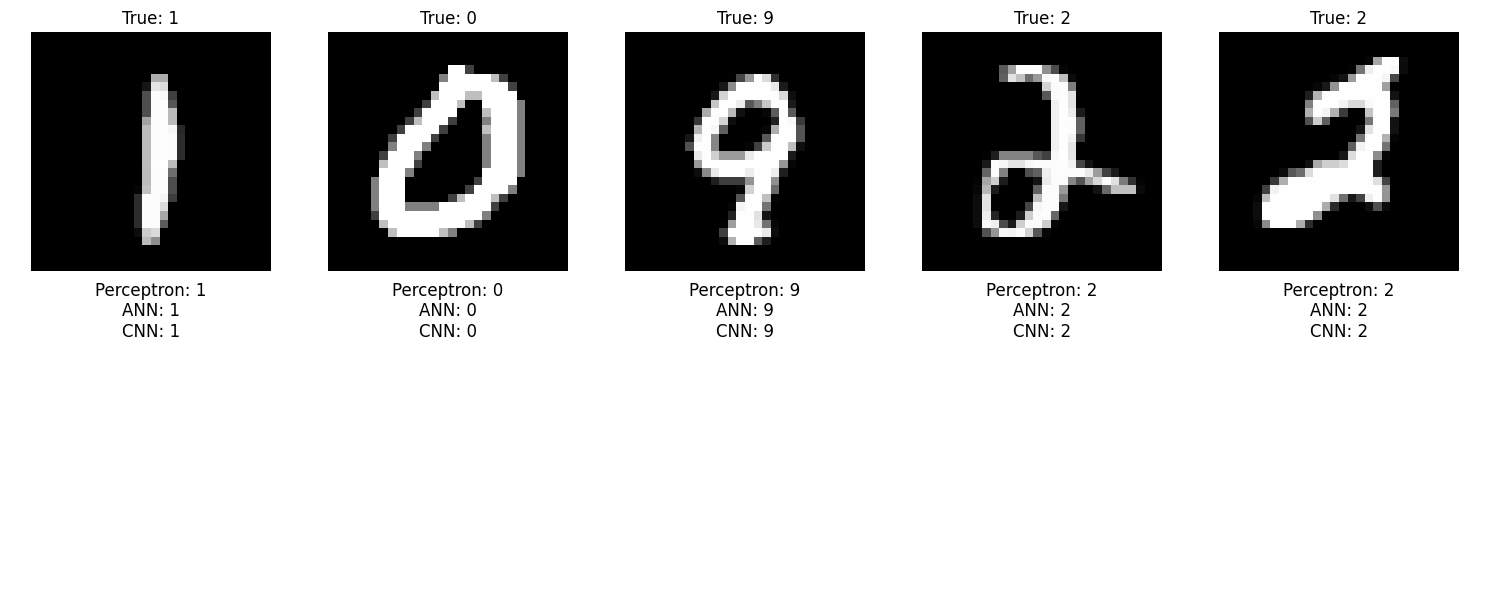

In [26]:
show_side_by_side([Perceptron,ann,cnn],['Perceptron','ANN','CNN'],X_test_img,X_test_cnn,y_test,5)

In [27]:
cnn.save("cnn_model.keras")